# 03. Prior Monte Carlo cache

Stage 1 of the SIR workflow: forward-simulate a Latin hypercube sample
of 2000 parameter sets, apply a behavioural filter (NSE_Q >= 0.3),
and subsample to a 500-member working ensemble.

This notebook is a thin wrapper around `scripts/run_prior_mc.py`.
For production runs, prefer the script (it supports multiprocessing).

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scripts.run_prior_mc import sample_lhs, PRIOR_BOUNDS, PARAM_NAMES

## Sample Latin hypercube prior (Latin hypercube sampling, LHS)

In [2]:
N_LHS = 2000   # Manuscript Section 2.3
SEED  = 0

prior = sample_lhs(N_LHS, seed=SEED)
print(prior.head())

            K_s       psi   theta_d          K_ex     f_sat     S_max  \
0  4.341917e-07  0.127760  0.251925  5.610620e-07  0.181648  0.055437   
1  3.360564e-07  0.198475  0.212270  4.013475e-05  0.202322  0.018047   
2  7.197071e-07  0.357557  0.280295  1.848591e-07  0.172559  0.064072   
3  2.349930e-07  0.272443  0.191911  2.120786e-05  0.104396  0.032411   
4  5.640242e-07  0.151657  0.189330  1.484226e-06  0.195088  0.086436   

      tau_drain  uh_stretch         n    V_soil  alpha_soil  Q_threshold  \
0  21230.759173    5.029447  0.048687  0.284704    0.980046     0.868199   
1  19783.453915    7.784153  0.058705  0.121052    0.866904     0.924901   
2  39108.058185    7.279387  0.039246  0.205624    0.578357     0.395006   
3  16452.912160    7.825432  0.039784  1.655982    0.998462     0.756139   
4  14116.617333    6.778703  0.048735  0.089374    0.611593     0.231938   

      gamma  lambda_sat  baseflow_Q  
0  4.071714    0.145224    0.150683  
1  4.220029    0.791214    0

## Visualise prior marginals

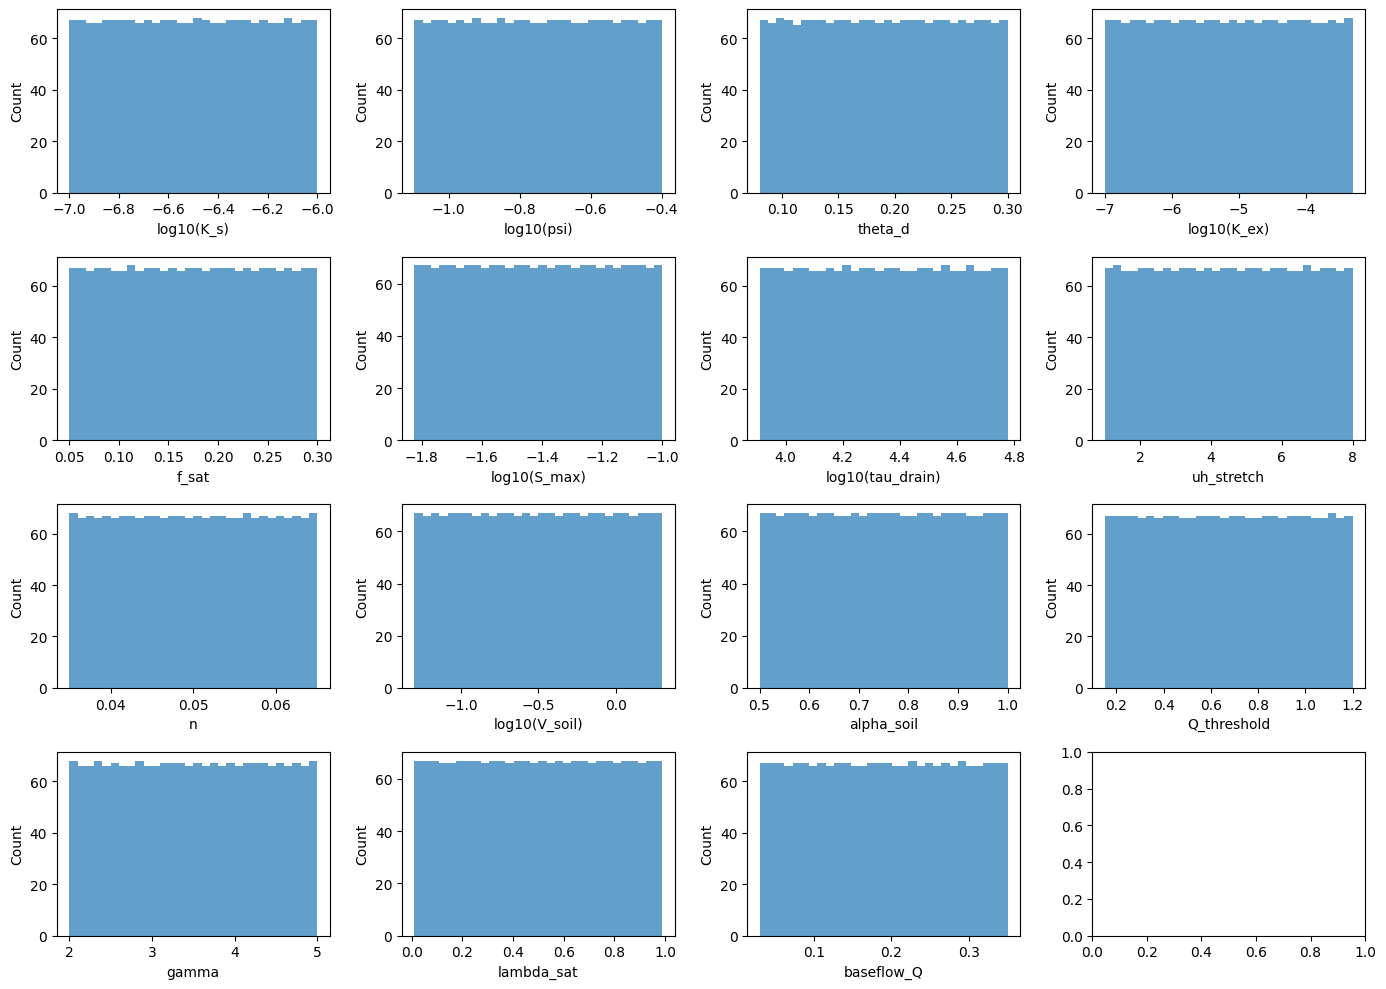

In [3]:
fig, axes = plt.subplots(4, 4, figsize=(14, 10))
for ax, p in zip(axes.flat, PARAM_NAMES):
    lo, hi, scale = PRIOR_BOUNDS[p]
    if scale == "log":
        ax.hist(np.log10(prior[p].values), bins=30, color="C0", alpha=0.7)
        ax.set_xlabel(f"log10({p})")
    else:
        ax.hist(prior[p].values, bins=30, color="C0", alpha=0.7)
        ax.set_xlabel(p)
    ax.set_ylabel("Count")
plt.tight_layout()

## Run the script

For the full N=2000 simulation, run the following from the repository root:
```bash
python scripts/run_prior_mc.py --storm-id 33 --n-lhs 2000 --n-workers 8
```

This will produce `outputs/prior_mc_storm33.csv` containing the
sampled parameters, simulation success flag, NSE_Q/NSE_C/KGE_Q/KGE_C
metrics, and a `working_ensemble` flag selecting the 500-member subset.

## Inspect the output (after the script has been run)

In [4]:
# Optional: load the generated prior MC table
try:
    out = pd.read_csv("../outputs/prior_mc_storm33.csv")
    print(f"Total rows:        {len(out)}")
    print(f"Successful:        {out['success'].sum()}")
    print(f"Behavioural:       {(out['NSE_Q'] >= 0.3).sum()}")
    print(f"Working ensemble:  {out['working_ensemble'].sum()}")
except FileNotFoundError:
    print("Run scripts/run_prior_mc.py first to generate the prior MC table.")

Total rows:        2000
Successful:        2000
Behavioural:       1853
Working ensemble:  500
